# ***`Titanic, группировка и сравнение`***

### Задание 1: ***Загрузка данных***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset('titanic')
print("✅ Данные загружены\n")

✅ Данные загружены



### ЗАДАНИЕ 2: ***ЗНАКОМСТВО***

In [2]:
print("Размер:", titanic.shape)
print("\nСтолбцы:", titanic.columns.tolist())
print("\nТипы данных:\n", titanic.dtypes)

Размер: (891, 15)

Столбцы: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Типы данных:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


### Задание 3. ***Анализ пассажиров***

In [4]:
print("\nПассажиры по классам:\n", titanic['pclass'].value_counts().sort_index())
print("\nПо полу:\n", titanic['sex'].value_counts())

bins = [0, 12, 18, 30, 45, 60, 100]
labels = ['Дети', 'Подростки', 'Молодые', 'Взрослые', 'Средний', 'Пожилые']
titanic['age_group'] = pd.cut(titanic['age'], bins=bins, labels=labels)
print("\nВозрастные группы:\n", titanic['age_group'].value_counts().sort_index())
print("\nСредний возраст:", round(titanic['age'].mean(), 2))
print("Медианный возраст:", titanic['age'].median())
print("Средняя стоимость билета:", round(titanic['fare'].mean(), 2))


Пассажиры по классам:
 pclass
1    216
2    184
3    491
Name: count, dtype: int64

По полу:
 sex
male      577
female    314
Name: count, dtype: int64

Возрастные группы:
 age_group
Дети          69
Подростки     70
Молодые      270
Взрослые     202
Средний       81
Пожилые       22
Name: count, dtype: int64

Средний возраст: 29.7
Медианный возраст: 28.0
Средняя стоимость билета: 32.2


### ЗАДАНИЕ 4: ***СРАВНЕНИЕ КЛАССОВ***

In [5]:
print("\nСредняя стоимость билета по классам:\n",
      titanic.groupby('pclass')['fare'].mean().round(2))
print("\nСредний возраст по классам:\n",
      titanic.groupby('pclass')['age'].mean().round(2))
print("\nПол по классам:\n",
      titanic.groupby(['pclass', 'sex']).size().unstack())
print("\nБольше всего пассажиров в классе:",
      titanic['pclass'].value_counts().idxmax())

max_fare = titanic.loc[titanic['fare'].idxmax()]
print("\nСамый дорогой билет:")
print(max_fare[['pclass', 'age', 'sex', 'fare', 'survived']])


Средняя стоимость билета по классам:
 pclass
1    84.15
2    20.66
3    13.68
Name: fare, dtype: float64

Средний возраст по классам:
 pclass
1    38.23
2    29.88
3    25.14
Name: age, dtype: float64

Пол по классам:
 sex     female  male
pclass              
1           94   122
2           76   108
3          144   347

Больше всего пассажиров в классе: 3

Самый дорогой билет:
pclass             1
age             35.0
sex           female
fare        512.3292
survived           1
Name: 258, dtype: object


**Вывод:** пассажиры 1-го класса платили в среднем в 6 раз больше, чем в 3-м (84-14), и были старше (38-25 лет). Больше всего пассажиров (491) ехало в 3-м классе.
Самый дорогой билет - у 35-летней женщины из 1-го класса, она выжила.

### ЗАДАНИЕ 5: ***ВЫЖИВАЕМОСТЬ***

In [6]:
print("\nВыжившие/погибшие:\n", titanic['survived'].value_counts())
print("\nВыживаемость по полу:\n",
      titanic.groupby('sex')['survived'].mean().round(3))
print("\nВыживаемость по классу и полу:\n",
      titanic.groupby(['pclass', 'sex'])['survived'].mean().round(3))

surv = titanic.groupby(['pclass', 'sex'])['survived'].mean()
print(f"\nЛучшая группа: класс {surv.idxmax()[0]}, {surv.idxmax()[1]} — {surv.max():.1%}")


Выжившие/погибшие:
 survived
0    549
1    342
Name: count, dtype: int64

Выживаемость по полу:
 sex
female    0.742
male      0.189
Name: survived, dtype: float64

Выживаемость по классу и полу:
 pclass  sex   
1       female    0.968
        male      0.369
2       female    0.921
        male      0.157
3       female    0.500
        male      0.135
Name: survived, dtype: float64

Лучшая группа: класс 1, female — 96.8%


**Вывод:** выжило 342 человека из 891 (38%). Женщины выживали в 4 раза чаще мужчин (74% против 19%). Лучшая группа - женщины 1-го класса (96.8%).
Хуже всего - мужчины 3-го класса (13.5%).

### ЗАДАНИЕ 6: ***ВИЗУАЛИЗАЦИЯ***

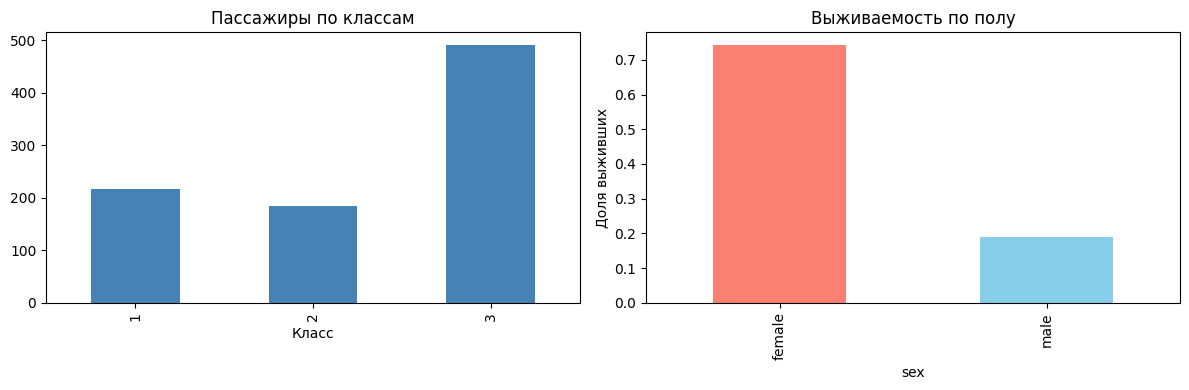

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
titanic['pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Пассажиры по классам')
axes[0].set_xlabel('Класс')

titanic.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[1], color=['salmon','skyblue'])
axes[1].set_title('Выживаемость по полу')
axes[1].set_ylabel('Доля выживших')
plt.tight_layout()
plt.show()

### Вопрос: ***подтверждается ли правило «женщины и дети - первыми»?***

In [11]:
titanic['first_letter'] = titanic['who'].str[0].str.upper()
result = titanic.groupby('first_letter')['survived'].agg(['mean', 'count'])
result = result[result['count'] > 20].round(3)
print(result.sort_values('mean', ascending=False))

               mean  count
first_letter              
W             0.756    271
C             0.590     83
M             0.164    537


**Вывод:** результат подтверждает правило «женщины и дети - первыми»:
группа W (women) - 75.6% выживших, C (children) - 59%, M (men) - 16.4%.